We are using the theta method, an implicit method for solving ODEs. We apply the fourier transform to the cahn-hilliard equation giving us a linear np.expression for the time derivative of u. This can be concidered as our F(t, U). 
$$
\partial_{t}\hat{u} = \hat{g} - \kappa |\tilde{k}|^4\hat{u}
$$


As we are using an implicit method, we solve U(n+1) as shown in the theory. 

The code initially finds the sampling frequencies, then find the starting point in fourier space U0, at t0. We then sole the time dependent part of the differential equation using the solution of the linear equation mentioned. For each time step we yield the solution and time.

    """
    $/del_{t}u^ = g^ - /kappa k˜^{2}u^$.
    Solve the transient biharmonic equation using the theta method.

    Parameters:
    ----------- 
    kappa (float): Diffusion coefficient.
    X (ndarray): 2D array of x-coordinates.
    Y (ndarray): 2D array of y-coordinates.
    U0 (ndarray): Initial condition array.
    t0 (float): Initial time.
    T (float): Final time.
    Nt (int): Number of time steps.
    g (callable, optional): Source term function g(X, Y, t). Defaults to None.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.
    """


## Imports, solver, global variables, plot function

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd

In [ ]:
def transient_biharmonic_solver(*, kappa, X, Y, U0, t0, T, Nt, Lx, Ly, theta=0.5, g=None):

    # Lager frekvensrommet
    Nx, Ny = X.shape 
    kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, sparse=True)

    # Definerer k**4 til senere bruk
    k4 = (KX**2 + KY**2)**2

    # Finner initialbetingelsene i frekvensrommet og tidssteg
    U_hat0 = fft2(U0)
    U_hat = U_hat0
    t = t0
    dt = (T-t0)/Nt

    yield U_hat0, t     # Yielder init. bet. i frekvensrom
    
    if g is None:       # Håndterer tilfellet at g ikke er en kallbar funksjon (Homogen likning)
        g = lambda x, y, t: np.zeros_like(U_hat)
    
    while t < T-dt/2:
        g_now = fft2(g(X, Y, t))        # g(n)
        g_next = fft2(g(X , Y, t+dt))   # g(n+1)
        
        # Benytter løsning av lineær likning for å finne U(n+1) implisitt
        U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)
        
        t+=dt # Oppdaterer tid

        yield U_hat, t # Yielder nåværende løsning

        
        
        

#### Definerer variabler som forblir uendret gjennom hele oppgaven

In [68]:
Nx, Ny = 20, 20             # Antall romlige sampling punkter
Lx, Ly = 2*np.pi, 2*np.pi   # Størrelse på romlig domene
lam = 4                     # Den beregnede lambda som gir homogent tilfelle g=0
kappa = 1 
t0 = 0
T = 1

# Definerer romlig domene symmetrisk om origo
x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False) 
y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')  # Shape: (Nx, Ny)


Nts = [10, 20, 40, 80, 160, 320, 640]

In [ ]:
def plot(Uex,U):
    fig = plt.figure(figsize=(20, 5))
    ax = fig.add_subplot(131, projection='3d')
    surf = ax.plot_surface(X, Y, Uex, cmap='viridis', antialiased=True)
    fig.colorbar(surf, shrink=0.6)
    ax.set_title("Exact solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U_\mathrm{ex}$')

    ax = fig.add_subplot(132, projection='3d')
    surf = ax.plot_surface(X, Y, U, cmap='viridis')
    fig.colorbar(surf, shrink=0.6)
    ax.set_title("Numerical solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U(X, Y)$')


    print(f"Error norm: {np.linalg.norm(U_err)}")
    ax = fig.add_subplot(133, projection='3d')
    surf = ax.plot_surface(X, Y,  U_err, cmap='viridis')
    fig.colorbar(surf, shrink=0.6)
    ax.set_title("Error")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U-U_{\mathrm{ex}}$')

    fig.suptitle(f"Theta = {theta}, Nt = {Nt}", fontsize=16)
    plt.show()

## A first tester solution

Error norm: 0.0006104192556393819


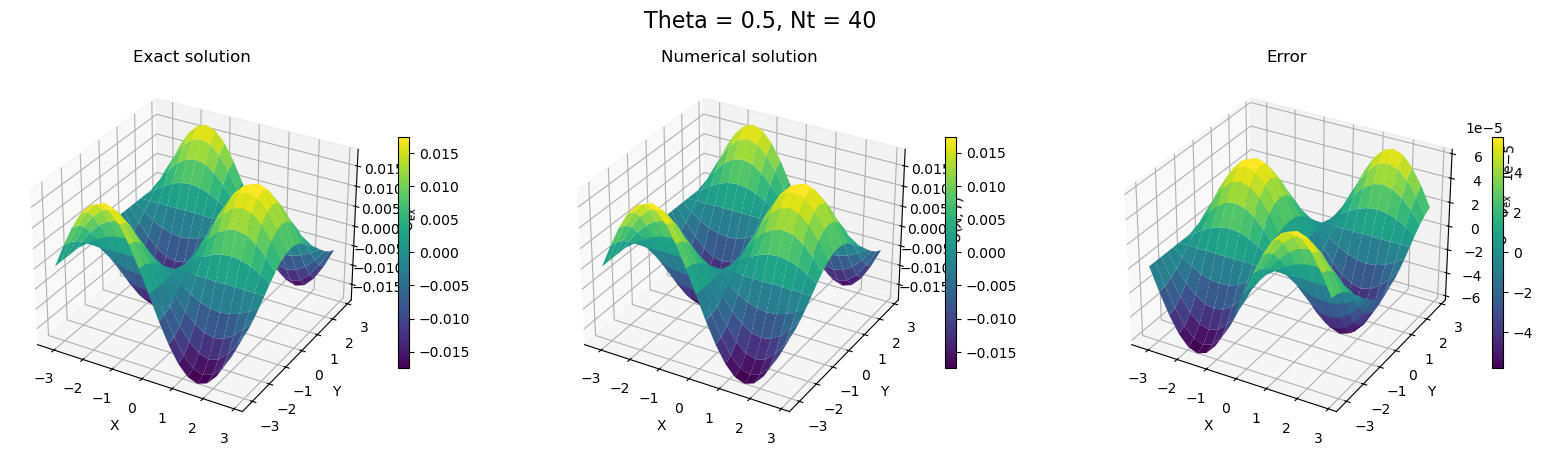

In [91]:
# Implementerer den første konstruerte løsningen
u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)

U0 = u_ex(X, Y, t0) # Initialbetingelse
theta = 0.5         
Nt = 40

solver = transient_biharmonic_solver(kappa=kappa, 
                                     X=X, Y=Y, U0=U0, 
                                     t0=t0, T=T, Nt=Nt,
                                     Lx=Lx, Ly=Ly,
                                     theta=theta,
                                     g=None)


# Itererer gjennom tuple objektet som gis av funksjonen og oppdaterer slik at vi plotter løsning ved T=1
for Uhat, t in solver: 
    
    U = ifft2(Uhat).real # Finner U i fysisk rom ved invers fourier transform
    Tfinal = t

Uex = u_ex(X, Y, Tfinal) # Beregner eksakt løsn. ved T=1 på samme fysiske domenet som num. løsn.

U_err = U - Uex # Finner enkel feil  til illustrasjon

plot(Uex, U)


## Theta = 1, 0.5, 0

Error norm: 0.07768414415854695


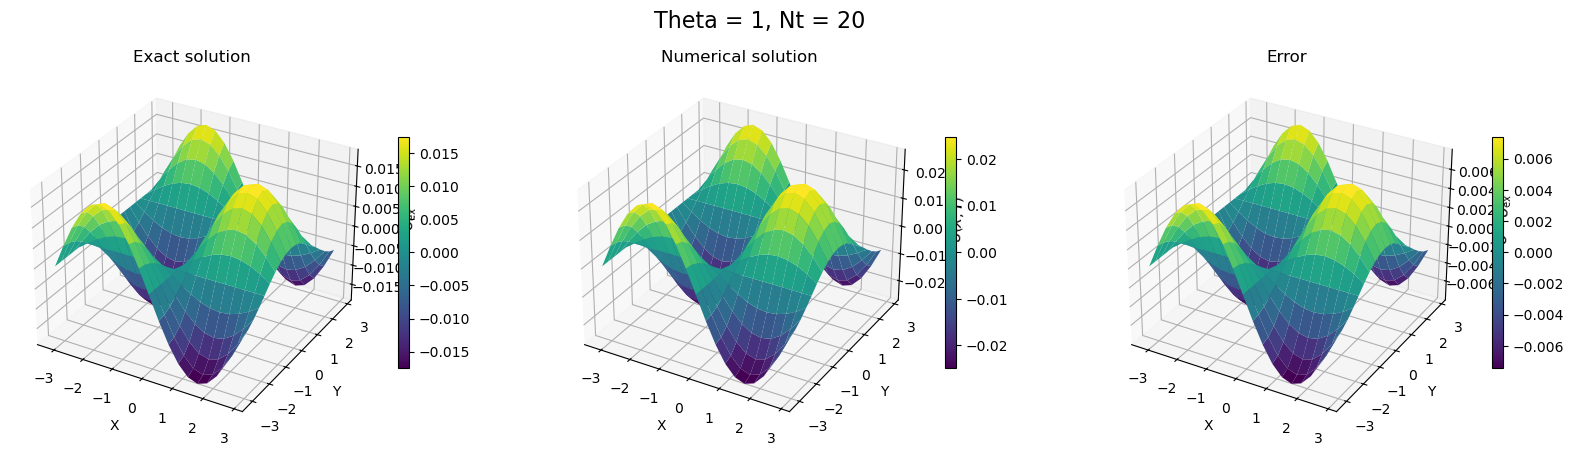

Error norm: 0.002440438673537998


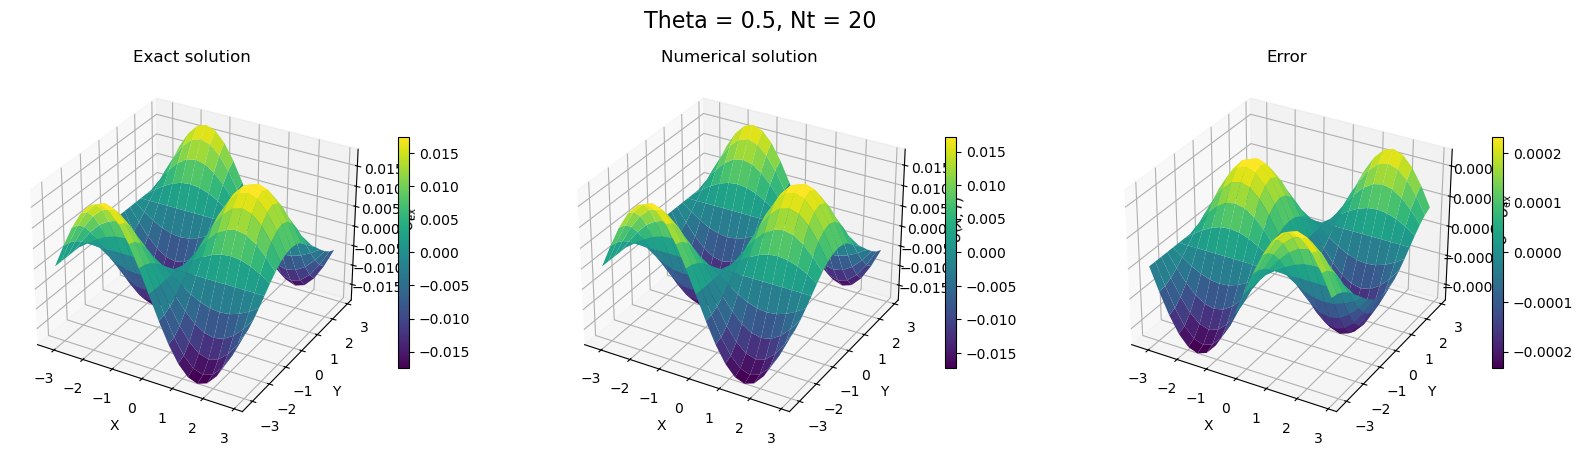

Error norm: 2.449673876391123e+47


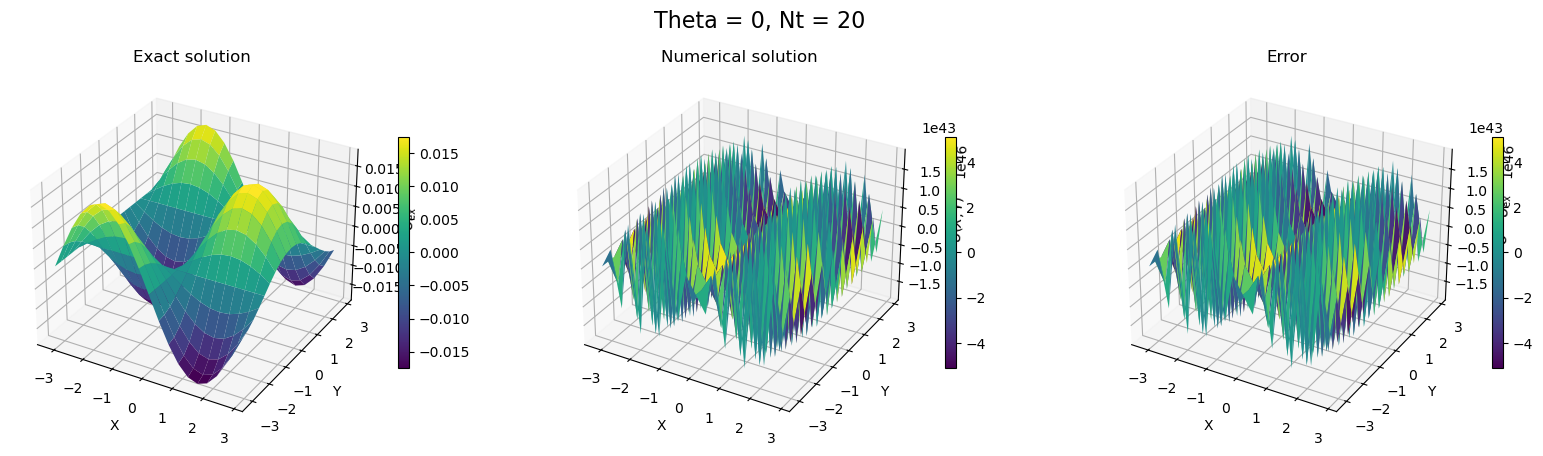

Error norm: 0.009233187025514072


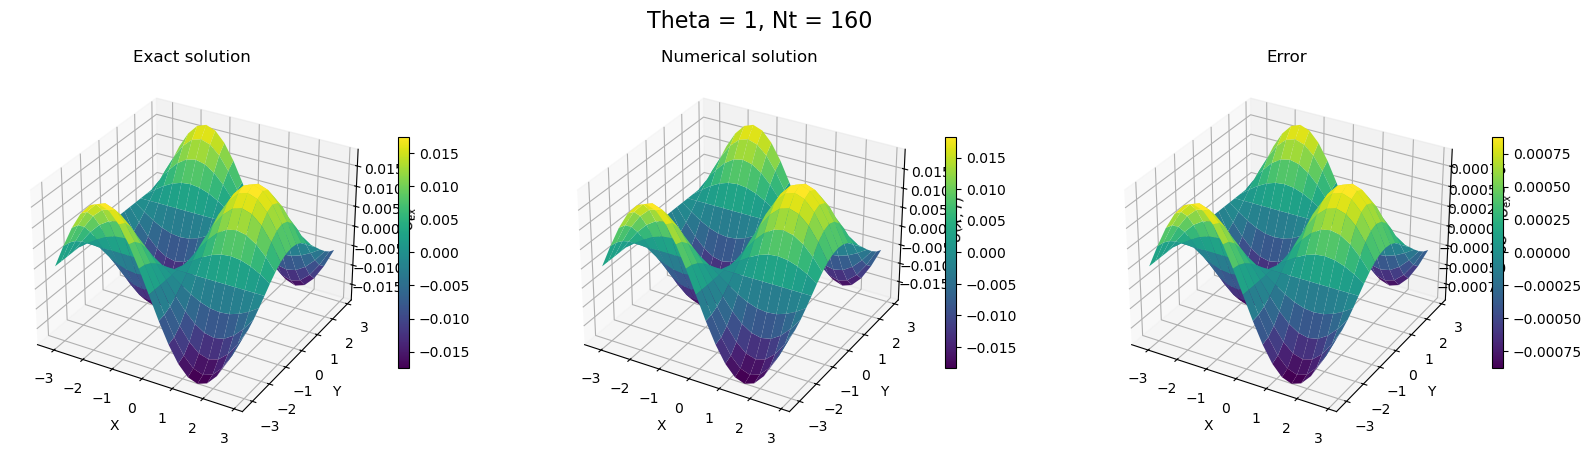

Error norm: 3.8157183473469986e-05


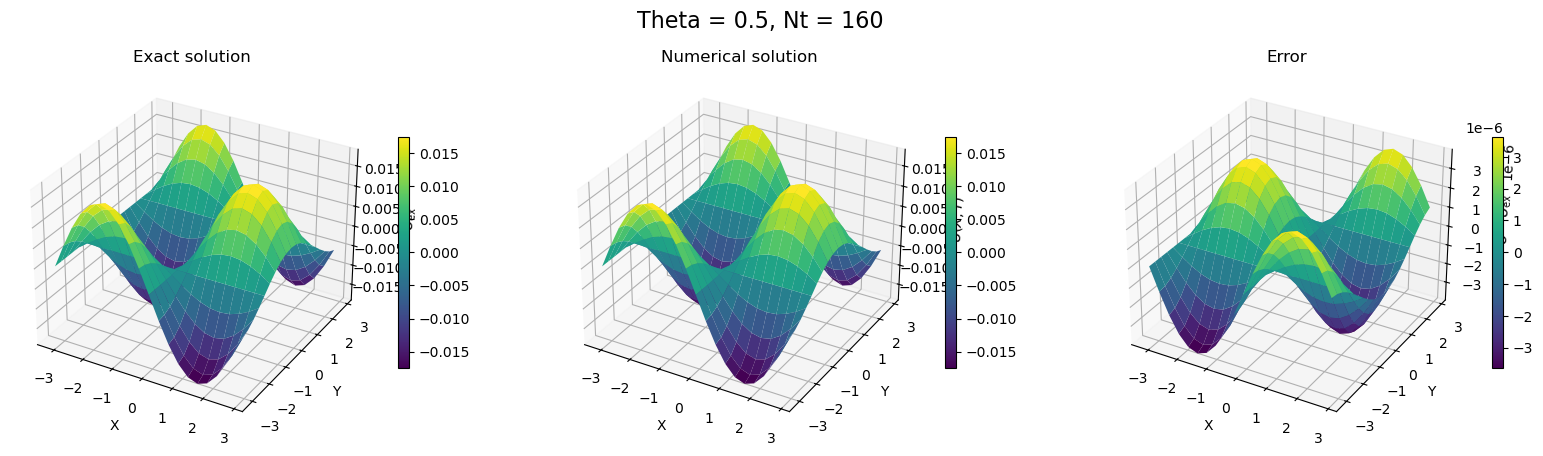

/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_9108/949670514.py:32: RuntimeWarning: overflow encountered in multiply
  U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)
/var/folders/7f/dgqrww_j5zzb5rrgh4w835f00000gp/T/ipykernel_9108/949670514.py:32: RuntimeWarning: invalid value encountered in multiply
  U_hat = (U_hat+dt*(theta*g_next+(1-theta)*(g_now - kappa*k4 * U_hat)))/(1+dt*theta*kappa*k4)


Error norm: nan


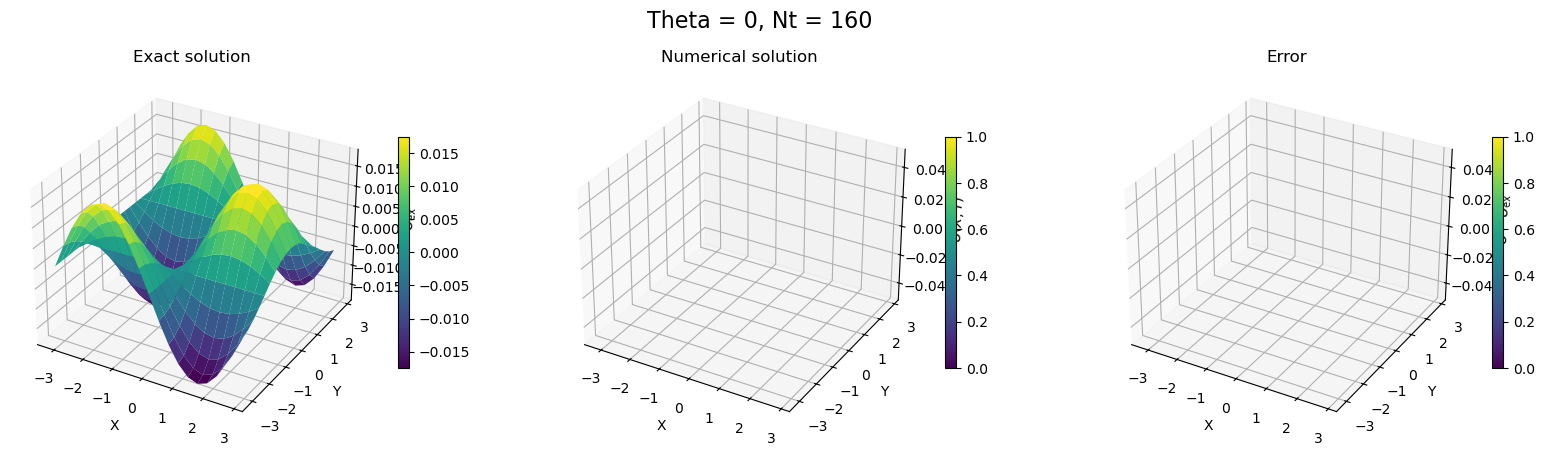

Error norm: 0.0022942096782487993


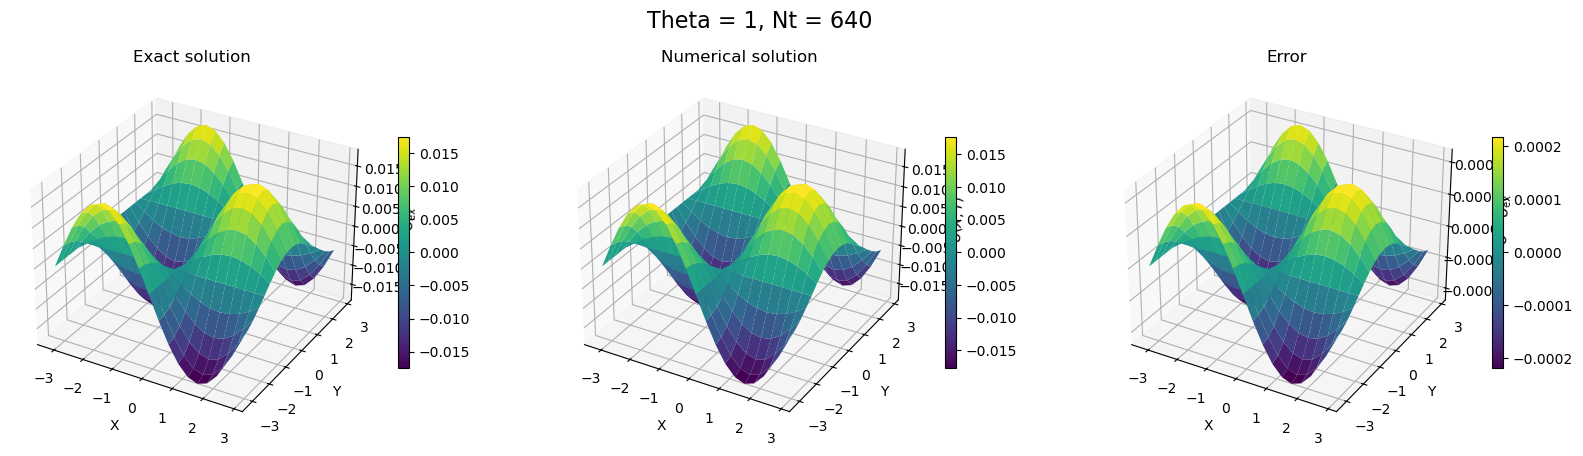

Error norm: 2.3848472533341014e-06


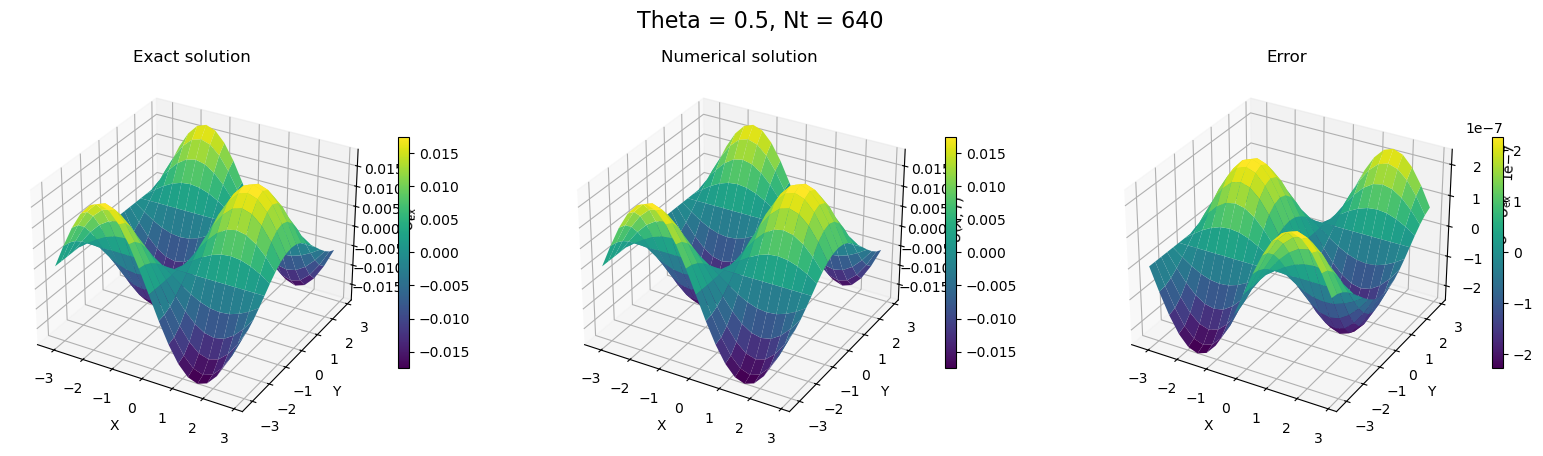

Error norm: nan


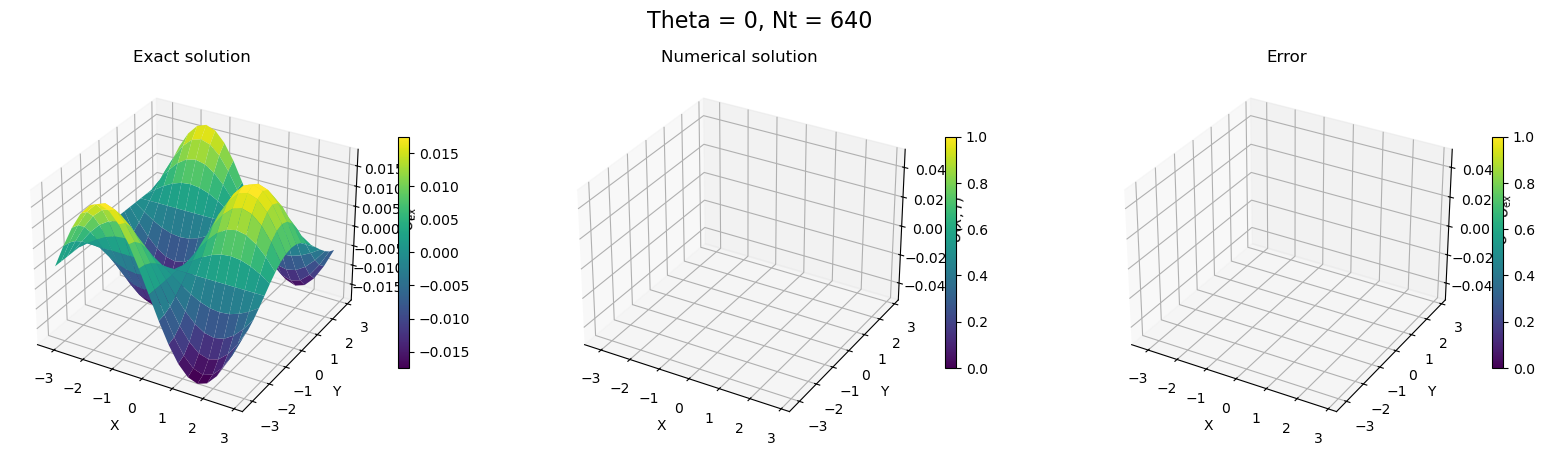

In [ ]:
# Første konstruerte løsning
u_ex = lambda x, y, t: np.sin(x)*np.cos(y)*np.exp(-lam * kappa * t)

U0 = u_ex(X, Y, t0) # Initialbetingelse
theta = 1         
Nts_plot = [20, 160, 640]
thetas = [1, 0.5, 0]

for Nt in Nts_plot:
    for theta in thetas:
        solver = transient_biharmonic_solver(kappa=kappa, 
                                            X=X, Y=Y, U0=U0, 
                                            t0=t0, T=T, Nt=Nt,
                                            Lx=Lx, Ly=Ly,
                                            theta=theta,
                                            g=None)


        # Itererer gjennom tuple objektet som gis av funksjonen og oppdaterer slik at vi plotter løsning ved T=1
        for Uhat, t in solver: 
            
            U = ifft2(Uhat).real # Finner U i fysisk rom ved invers fourier transform
            Tfinal = t

        Uex = u_ex(X, Y, Tfinal) # Beregner eksakt løsn. ved T=1 på samme fysiske domenet som num. løsn.

        U_err = U - Uex # Finner enkel feil  til illustrasjon
        plot(Uex, U)




## Feil

In [92]:
def compute_eoc_transient(*,
                          kappa, u_ex, U0, g,
                          X, Y, t0, T, Nt_list):
    errs_Nt = [] 
    for Nt in Nt_list:
        U_list = transient_biharmonic_solver(kappa=kappa, 
                                     X=X, Y=Y, U0=U0, 
                                     t0=t0, T=T, Nt=Nt, 
                                     Lx=Lx, Ly=Ly,
                                     g=g)
        errs_t = []
        for U, t in U_list:
            U_ex = u_ex(X,Y,t)
            U_err = U - U_ex
            # Record maximum error at current time step
            errs_t.append(np.linalg.norm(U_err, np.inf))
        # Record maximum error over all time steps 
        errs_Nt.append(np.array(np.linalg.norm(errs_t, np.inf)))
        
    Nt_list = np.array(Nt_list)
    errs_Nt = np.array(errs_Nt)
    eocs = np.log(errs_Nt[1:]/errs_Nt[:-1])/np.log(Nt_list[:-1]/Nt_list[1:])
    eocs = np.insert(eocs, 0, np.inf)
    return errs_Nt, eocs

In [93]:
thetas = [0.5, 1]
Nts = [10, 20, 40, 80, 160, 320, 640]

errs_across_thetas = []

# for theta in thetas:
#     err_theta = []
#     for Nt in Nts:

#         solver = transient_biharmonic_solver(kappa=kappa, 
#                                             X=X, Y=Y, U0=U0, 
#                                             t0=t0, T=T, Nt=Nt,
#                                             Lx=Lx, Ly=Ly, 
#                                             theta=theta,
#                                             g=None)



#         for Uhat, t in solver:
#             U = ifft2(Uhat).real
#             Tfinal = t
            
#         Uex = u_ex(X, Y, Tfinal)
#         U_err = Uex - Uhat
#         err_max = np.max(np.abs(U_err))
#         err_theta.append(err_max)

#     errs_across_thetas.append(err_theta) 


# EOCs = [[]]
# for i in range(len(thetas)):
#     errs = np.array(errs_across_thetas[i])
#     dts = (T-t0)/np.array(Nts)
#     eoc = np.log(errs[1:]/errs[:-1])/np.log(dts[1:]/dts[:-1])
#     EOCs.append(eoc)

for theta in thetas:
    errs_Nt, eocs = compute_eoc_transient(kappa=kappa, u_ex=u_ex, U0=U0, g=None,
                            X=X, Y=Y, t0=t0, T=T, Nt_list=Nts)
    
    # Create a dataframe
    df = pd.DataFrame()
    df['Nt'] = Nts
    df[f'L inf error theta = {theta}'] = errs_Nt
    df[f'EOC theta = {theta}'] = eocs
    # show datafram in a better format
    display(df)


,Nt,L inf error theta = 0.5,EOC theta = 0.5
0,10,203.315192,inf
1,20,203.315192,-0.0
2,40,203.315192,-0.0
3,80,203.315192,-0.0
4,160,203.315192,-0.0
5,320,203.315192,-0.0
6,640,203.315192,-0.0


,Nt,L inf error theta = 1,EOC theta = 1
0,10,203.315192,inf
1,20,203.315192,-0.0
2,40,203.315192,-0.0
3,80,203.315192,-0.0
4,160,203.315192,-0.0
5,320,203.315192,-0.0
6,640,203.315192,-0.0


## CFL krav for stabilitet og konvergens

CFL krav forteller oss noe om sammenhengen mellom stabilitetsfunksjonen og stegstørrelse for en løsningsmetode.
Vi tar utgangspunkt i Un+1 = (1-tau(1-teta)lambda)/(1+tau* teta* lambda) * Un. Herfra kan vi se at veksten mellom steg kan måles med G, der abs(G) = abs(Un+1/Un)= abs((1-tau(1-teta)lambda)/(1+tau * teta*lambda)). Og dette forholdet burde være mindre enn 1 for å unngå at løsningen plutselig eksploderer slik den gjør i stive problemer. Ser vi på teta = 0 ser vi at vi må ha abs(1-tau * lambda)<=1 og dermed 0<= tau * lamda <= 2. Med lambda lik kappa * k4 slik den er for den biharmoniske operator, gir dette kravet tau = 2/(kappa * k4). 
k4 er (2pi kx/Lx) ** 4. Og kx er maksimalt lik Nx slik at k4 max = (2 pi Nx/Lx) ** 4. Da er tau maksimalt lik 


IKKE FERDIG

## Inhomogen likning

In [88]:
# Bruker kode fra forelesningsnotater for å finne g
def manufacture_solution_biharmonic(u_str, kappa, M, f):
    import sympy as sy
    from sympy import sin, cos, exp
    x, y, t = sy.symbols('x y t')
    u_sy = eval(u_str) # symbolsk representasjon av u evalueres fra strengen
    laplace = lambda u: sy.diff(u, x, x) + sy.diff(u, y, y) # Definerer laplace
    g_sy =  sy.diff(u_sy, t) - sy.simplify(M*laplace(f(u_sy)))+sy.simplify(kappa*(laplace(laplace(u_sy))))  # skriver uttrykk for g
    
    # funksjonene gjøres til kallbare funksjoner og printes
    u = sy.lambdify((x, y, t), u_sy, modules='numpy') 
    g = sy.lambdify((x, y, t), g_sy, modules='numpy')
    print(f'u = {u_sy}') 
    print(f'u0 = {u_sy.subs(t, 0)}')
    print(f'g = {g_sy}')
    return u, g

M = 1
f = lambda u : u**3 - u
u_ex_str = '(exp(1+sin(x)*sin(x))+exp(1+cos(y)*cos(y)))*exp(-4*kappa*t)'
u_ex, g = manufacture_solution_biharmonic(u_ex_str, kappa, M, f)

u = (exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*t)
u0 = exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1)
g = -4*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*t) + 4*(4*exp(1 - sin(y)**2)*sin(y)**8 - 32*exp(1 - sin(y)**2)*sin(y)**6 + 68*exp(1 - sin(y)**2)*sin(y)**4 - 44*exp(1 - sin(y)**2)*sin(y)**2 + 5*exp(1 - sin(y)**2) + 4*exp(sin(x)**2)*sin(x)**8 + 16*exp(sin(x)**2)*sin(x)**6 - 4*exp(sin(x)**2)*sin(x)**4 - 12*exp(sin(x)**2)*sin(x)**2 + exp(sin(x)**2))*exp(1 - 4*t) - 2*(6*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(sin(x)**2 + 1)*sin(x)**2*cos(x)**2 - 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(sin(x)**2 + 1)*sin(x)**2 + 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(sin(x)**2 + 1)*cos(x)**2 + 6*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(cos(y)**2 + 1)*sin(y)**2*cos(y)**2 + 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(cos(y)**2 + 1)*sin(y)**2 - 3*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))**2*exp(cos(y)**2 + 1)*cos(y)**2 + 12*(exp(sin(x)**2 + 1) + exp(cos(y)**

Error norm: nan


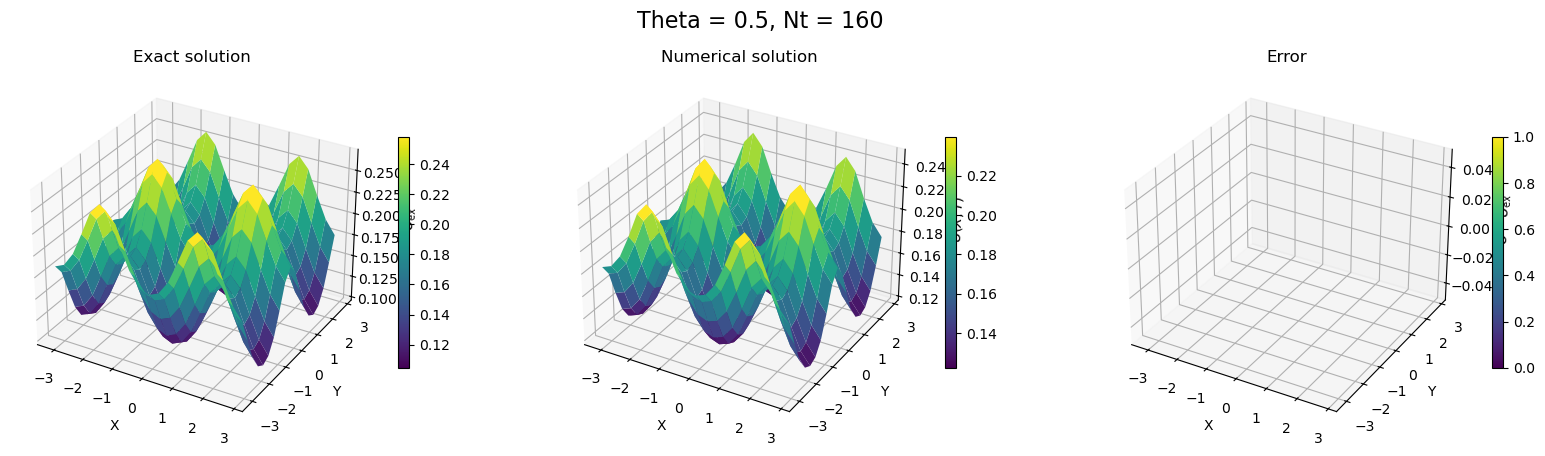

In [ ]:
# Kopierer tidligere løsning så vi slipper å kjøre blokken over gjentatte ganger
u_ex = lambda x, y, t: (np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(-4*t)
g = lambda x, y, t: -4*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(-4*t) + 4*(4*np.exp(1 - np.sin(y)**2)*np.sin(y)**8 - 32*np.exp(1 - np.sin(y)**2)*np.sin(y)**6 + 68*np.exp(1 - np.sin(y)**2)*np.sin(y)**4 - 44*np.exp(1 - np.sin(y)**2)*np.sin(y)**2 + 5*np.exp(1 - np.sin(y)**2) + 4*np.exp(np.sin(x)**2)*np.sin(x)**8 + 16*np.exp(np.sin(x)**2)*np.sin(x)**6 - 4*np.exp(np.sin(x)**2)*np.sin(x)**4 - 12*np.exp(np.sin(x)**2)*np.sin(x)**2 + np.exp(np.sin(x)**2))*np.exp(1 - 4*t) - 2*(6*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.sin(x)**2 + 1)*np.sin(x)**2*np.cos(x)**2 - 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.sin(x)**2 + 1)*np.sin(x)**2 + 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.sin(x)**2 + 1)*np.cos(x)**2 + 6*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.cos(y)**2 + 1)*np.sin(y)**2*np.cos(y)**2 + 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.cos(y)**2 + 1)*np.sin(y)**2 - 3*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))**2*np.exp(np.cos(y)**2 + 1)*np.cos(y)**2 + 12*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(3 - np.cos(2*x))*np.sin(x)**2*np.cos(x)**2 + 12*(np.exp(np.sin(x)**2 + 1) + np.exp(np.cos(y)**2 + 1))*np.exp(np.cos(2*y) + 3)*np.sin(y)**2*np.cos(y)**2 + (2*np.sin(x)**4 - 1)*np.exp(8*t + np.sin(x)**2 + 1) + (2*np.sin(y)**4 - 4*np.sin(y)**2 + 1)*np.exp(8*t + np.cos(y)**2 + 1))*np.exp(-12*t)


U0 = u_ex(X, Y, t0) 
theta = 0.5
Nt = 160

solver = transient_biharmonic_solver(kappa=kappa, 
                                     X=X, Y=Y, U0=U0, 
                                     t0=t0, T=T, Nt=Nt,
                                     Lx=Lx, Ly=Ly,
                                     theta=theta,
                                     g=g)



for Uhat, t in solver:
    
    U = ifft2(Uhat).real
    Tfinal = t

Uex = u_ex(X, Y, Tfinal)

plot(Uex, U)